# NOTEBOOK: Regression Model Comparison

Compare all regression models on California Housing dataset:
 - Linear Regression
 - Polynomial Regression
 - Ridge Regression
 - Lasso Regression
 - Decision Tree
 - Random Forest

## Setup

In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader
from src.preprocessing import DataPreprocessor
from src.data_utils import split_train_test
from src.models.supervised import (
    SKLearnLinearRegression,
    SKLearnRidgeRegression,
    SKLearnLassoRegression,
    SKLearnDecisionTreeRegressor,
    SKLearnRandomForestRegressor
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load & Preprocess Data

In [4]:
X, y = data_loader.load_california_housing()

# Split
X_train, X_test, y_train, y_test = split_train_test(X, y, test_size=0.2, random_state=42)

# Preprocess
preprocessor = DataPreprocessor(scale=True, encode_categorical=True) # Tree-based models don't need scaling but for comparison we scale all features
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Polynomial Regression
preprocessor_poly = DataPreprocessor(scale=True, encode_categorical=True, polynomial_degree=2) 
X_train_proc_poly = preprocessor_poly.fit_transform(X_train)
X_test_proc_poly = preprocessor_poly.transform(X_test)


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 8 columns
   Nominal categorical: 0 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...

4. Processing ordinal categorical columns...

6. Scaling features...
   ✓ Scaled 8 features

Final shape: 16512 rows × 8 features


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 8 columns
   Nominal categorical: 0 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...

4. Processing ordinal categorical columns...

5. Creating polynomial features (degree=2)...
   → Created 44 polynomial features

6. Scaling features...
   ✓ Scaled 44 features

Final shape: 16512 rows × 44 features



## Train All Models

In [5]:
models = {
    'Linear Regression': SKLearnLinearRegression(),
    'Ridge Regression': SKLearnRidgeRegression(alpha=100),
    'Lasso Regression': SKLearnLassoRegression(alpha=0.01),
    'Decision Tree': SKLearnDecisionTreeRegressor(max_depth=45),
    'Random Forest': SKLearnRandomForestRegressor(n_estimators=100, max_depth=45),
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train_proc, y_train)
    
    # Evaluate
    train_score = model.score(X_train_proc, y_train)
    test_score = model.score(X_test_proc, y_test)
    
    results.append({
        'Model': name,
        'Train R²': train_score,
        'Test R²': test_score,
        'Overfit': train_score - test_score
    })
    
    print(f"{name:20s} | Train: {train_score:.4f} | Test: {test_score:.4f}")

# Polynomial Regression
models.get('Linear Regression').fit(X_train_proc_poly, y_train)

# Evaluate
train_score_poly = models.get('Linear Regression').score(X_train_proc_poly, y_train)
test_score_poly = models.get('Linear Regression').score(X_test_proc_poly, y_test)

results.append({
        'Model': 'Polynomial Regression',
        'Train R²': train_score_poly,
        'Test R²': test_score_poly,
        'Overfit': train_score_poly - test_score_poly
    })
    
print(f"{'Polynomial Regression':20s} | Train: {train_score_poly:.4f} | Test: {test_score_poly:.4f}")

Linear Regression    | Train: 0.6126 | Test: 0.5758
Ridge Regression     | Train: 0.6120 | Test: 0.5778
Lasso Regression     | Train: 0.6085 | Test: 0.5816
Decision Tree        | Train: 1.0000 | Test: 0.6206
Random Forest        | Train: 0.9732 | Test: 0.8044
Polynomial Regression | Train: 0.6853 | Test: 0.6457


## Compare Results


Model Comparison (sorted by Test R²):
                   Model  Train R²   Test R²   Overfit
4          Random Forest  0.973159  0.804351  0.168808
5  Polynomial Regression  0.685268  0.645682  0.039586
3          Decision Tree  1.000000  0.620597  0.379403
2       Lasso Regression  0.608474  0.581615  0.026858
1       Ridge Regression  0.611957  0.577791  0.034166
0      Linear Regression  0.612551  0.575788  0.036763


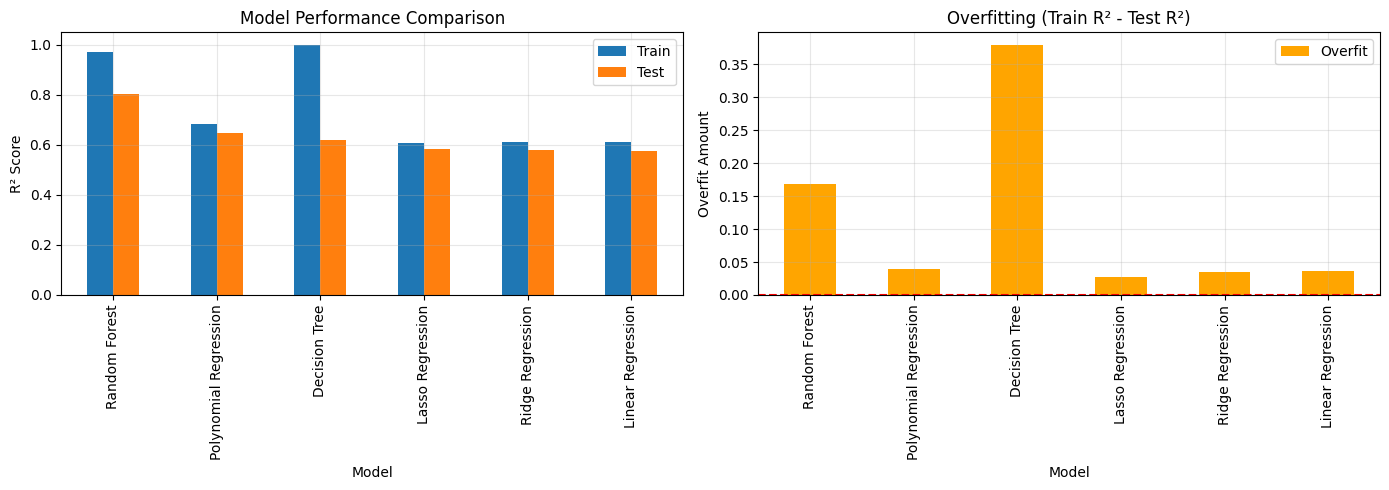

In [6]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False)

print("\nModel Comparison (sorted by Test R²):")
print(results_df)

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# R² comparison
results_df.plot(x='Model', y=['Train R²', 'Test R²'], kind='bar', ax=ax[0])
ax[0].set_title('Model Performance Comparison')
ax[0].set_ylabel('R² Score')
ax[0].legend(['Train', 'Test'])
ax[0].grid(True, alpha=0.3)

# Overfitting
results_df.plot(x='Model', y='Overfit', kind='bar', ax=ax[1], color='orange')
ax[1].set_title('Overfitting (Train R² - Test R²)')
ax[1].set_ylabel('Overfit Amount')
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusions

In [7]:
best_model = results_df.iloc[0]

print("\n" + "="*70)
print("FINAL CONCLUSIONS")
print("="*70)
print(f"Best model: {best_model['Model']}")
print(f"  Test R²: {best_model['Test R²']:.4f}")
print(f"  Overfit: {best_model['Overfit']:.4f}")


FINAL CONCLUSIONS
Best model: Random Forest
  Test R²: 0.8044
  Overfit: 0.1688
